# 1.- S04 | Practica guiada: de tablas a patrones visuales

Sesion 4 - Visualizacion y storytelling. Cierre del bloque de fundamentos
(S01-S04) del caso **No-Show Appointments**.


## 1.1.- Como usar este notebook

- Ejecuta en orden.
- Local: el dataset original esta en `Recursos/Datasets/noshowappointments/KaggleV2-May-2016.csv`; el path ya esta escrito en el setup.
- Colab: usa la celda comentada de carga (mas abajo) y adaptala a tus datos.
- Hoy no hay manipulacion de datos nueva: partimos del **original** y lo reconstruimos con **tus funciones de S03**. Las unicas herramientas nuevas son `matplotlib` y `seaborn`.


## 1.2.- Objetivos de la sesion

Al cerrar S04 debes poder:

1. Elegir la **familia de grafico** (Distribucion, Comparacion, Relacion, Composicion) para una pregunta de negocio, conociendo el menu de tipos de cada familia.
2. Distinguir `matplotlib` (motor) de `seaborn` (estadistica + estetica) y saber cual usar.
3. Construir graficos que responden las hipotesis priorizadas de S03 (H1 espera, H2 edad, H3 barrio), cada uno con su lectura de negocio.
4. Pedir a un copilot el codigo de un grafico sin que invente columnas ni librerias.
5. Reconstruir el viaje S01->S04 y abstraer un **worksheet agnostico** aplicable a cualquier caso.
6. Cerrar el Project Canvas (v4) con evidencia visual defendible.


# 2.- B0 - Apertura: de S03 a la comunicacion visual

> Lente principal: `CRISP-DM: Data Understanding`. Visualizar no es decorar: es **seguir entendiendo** y hacer comunicable la evidencia.


## 2.1.- Que traemos de S03

| Punto | Evidencia |
|---|---|
| Dataset | el original (110.527 citas) preparado con `prepare()` + `enrich()` -> 110.521 x 24 |
| Baseline | tasa de no-show ~20,2 % |
| Variables derivadas | `WaitingBin`, `AgeGroup`, `LongWait`, `NoShowRate_by_Neigh`, `Hotspot` |
| Hipotesis priorizadas | **H1** espera · **H2** edad · **H3** barrio |


## 2.2.- CRISP-DM: posicion de S04

| Fase | En el curso |
|---|---|
| Business Understanding | S01 |
| **Data Understanding** | S01 demo, S02, **S04 (hoy: comunicacion visual)** |
| Data Preparation | S03, S05 |
| Modeling / Evaluation | S05-S10 |
| Deployment | S11 |

Una tabla `groupby` ya es evidencia; un grafico la hace **comunicable** y revela patrones que la tabla esconde.


## 2.3.- Lentes de trabajo

| Lente | Uso en S04 |
|---|---|
| `EDA` | que forma tienen los datos (distribucion, relaciones) |
| `PECO` | que hipotesis confirma o cuestiona cada grafico |
| `comunicacion visual` | que insight extrae un stakeholder no tecnico |


## 2.4.- Mapa de la sesion S04 (dos bloques)

| Bloque | Foco | Producto |
|---|---|---|
| **1** (18:00-19:50) | marco viz + galeria + 4 graficos (predice-revela) + prompt-clinic | galeria + 4 graficos con lectura |
| **2** (20:10-22:00) | reel S01->S04 + worksheet agnostico + Canvas v4 | Canvas v4 defendible |

Tira conductora del Bloque 1: **pregunta -> familia -> grafico -> insight**.


# 3.- B1 - Marco de visualizacion: pensar antes de graficar

> Lente principal: `comunicacion visual`. La pregunta elige el grafico, no la estetica.


## 3.1.- Setup: del original a tu dataset preparado

Partimos del CSV **original** y lo reconstruimos con las funciones que hiciste en S03.
Primero, el recordatorio de esas funciones (no son nuevas):


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")          # estetica por defecto de seaborn
pd.set_option("display.max_columns", None)

RAW_PATH = "../../../../Recursos/Datasets/noshowappointments/KaggleV2-May-2016.csv"


def prepare_basic(df):
    """Limpieza + variables base de S02/S03 (NoShow, WaitingDays, weekday, filtro de validas)."""
    df = df.copy()                                                     # no mutar el DataFrame original
    df = df.rename(columns={"Hipertension": "Hypertension", "Handcap": "Handicap"})  # corregir nombres mal escritos
    df["NoShow"] = (df["No-show"] == "Yes").astype(int)                # objetivo 0/1: 1 = falto a la cita
    scheduled = pd.to_datetime(df["ScheduledDay"]).dt.normalize()      # texto -> fecha (a medianoche, sin hora)
    appointment = pd.to_datetime(df["AppointmentDay"]).dt.normalize()
    df["WaitingDays"] = (appointment - scheduled).dt.days              # espera = dias entre solicitud y cita
    df["AppointmentWeekday"] = appointment.dt.day_name()               # dia de la semana de la cita
    valid = (df["Age"] >= 0) & (df["WaitingDays"] >= 0)                # reglas de validez (edad y espera >= 0)
    return df.loc[valid].copy()                                        # devolver solo las filas validas


def prepare(df):
    """Amplia prepare_basic con las variables derivadas (binning + flags)."""
    df = prepare_basic(df)
    df["AgeGroup"] = pd.cut(df["Age"], bins=[-1, 12, 17, 35, 64, 200],          # edad continua -> etapas vitales
                            labels=["Ninez", "Adolescencia", "Joven", "Adulto", "Senior"])
    df["WaitingBin"] = pd.cut(df["WaitingDays"], bins=[-1, 3, 7, 14, 30, 10_000],  # espera -> tramos de negocio
                              labels=["0-3", "4-7", "8-14", "15-30", "30+"])
    df["LongWait"] = (df["WaitingDays"] > 14).astype(int)              # flag 0/1: espera larga
    df["IsWeekend"] = df["AppointmentWeekday"].isin(["Saturday", "Sunday"]).astype(int)  # flag 0/1: fin de semana
    return df


def enrich_with_neighbourhood_rate(df, min_n=50, hotspot_min_rate=0.22):
    """Anade la tasa de no-show por barrio y marca los barrios hotspot."""
    df = df.copy()
    neigh_rate = df.groupby("Neighbourhood").agg(                      # una fila por barrio: tasa y volumen
        NoShowRate_by_Neigh=("NoShow", "mean"),
        NCitas_by_Neigh=("NoShow", "size"),
    ).reset_index()
    df = df.merge(neigh_rate, on="Neighbourhood", how="left")          # reincorporar a cada cita (left = no perder filas)
    df["Hotspot"] = ((df["NoShowRate_by_Neigh"] >= hotspot_min_rate)   # hotspot = tasa alta Y muestra suficiente
                     & (df["NCitas_by_Neigh"] >= min_n)).astype(int)
    return df

Una linea reconstruye el dataset preparado a partir del original:


In [2]:
df = enrich_with_neighbourhood_rate(prepare(pd.read_csv(RAW_PATH)))
df.shape

(110521, 24)

**Carga en Colab (plantilla).** Para tu TFM, monta Drive y carga tus datos;
luego aplica tu propia preparacion (o `prepare()`/`enrich()` si trabajas el No-Show).


In [3]:
# import pandas as pd
# from google.colab import drive
#
# # Montar Drive y cargar dataset
# drive.mount("/content/drive")
# data_path = "/content/drive/MyDrive/Classroom/KaggleV2-May-2016.csv"
# df = pd.read_csv(data_path)
# df = enrich_with_neighbourhood_rate(prepare(df))   # para el No-Show

## 3.2.- Por que un grafico y no otro

- **Familia:** Conjunto de gráficos que responde el **mismo tipo** de pregunta.
    - **ver tablas** ---> **ver patrones**.
    - La **pregunta** elige la familia; la familia, el gráfico.
    - Un buen gráfico responde **una sola** pregunta.


| Pregunta de negocio | Familia | Grafico tipico |
|---|---|---|
| ¿Como se reparte una variable? | Distribucion | histograma, KDE, boxplot |
| ¿Quien tiene mas? | Comparacion | barras, countplot |
| ¿Como se relacionan dos variables? | Relacion | scatter, heatmap |
| ¿De que esta hecho el todo? | Composicion | barras apiladas 100 % (no pie chart) |


## 3.3.- matplotlib (motor) vs seaborn (coche)

| Herramienta | Rol | Pragmatica |
|---|---|---|
| `matplotlib` | el **motor**: control total | tu agregas los datos y etiquetas cada cosa; mas lineas |
| `seaborn` | el **coche**: estadistica + estetica | recibe el DataFrame y la columna, agrega y estiliza solo; menos lineas |

**Regla:** por defecto **seaborn** (lo que veras en toda la galeria); baja a **matplotlib** para control fino.

**Galerias oficiales** (clic para explorar mas tipos de forma interactiva):
- [Galeria de matplotlib](https://matplotlib.org/stable/gallery/index.html)
- [Galeria de seaborn](https://seaborn.pydata.org/examples/index.html)

Mismo grafico, las dos formas:


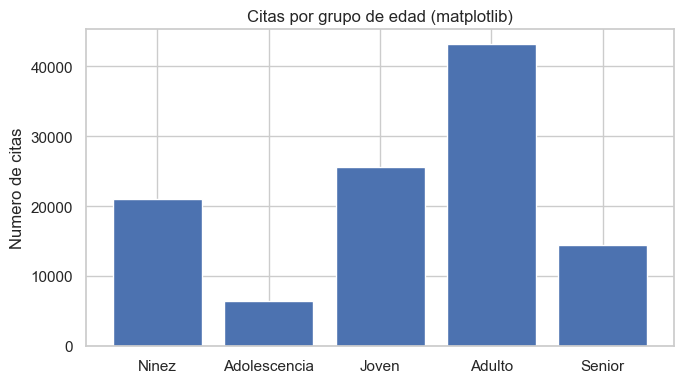

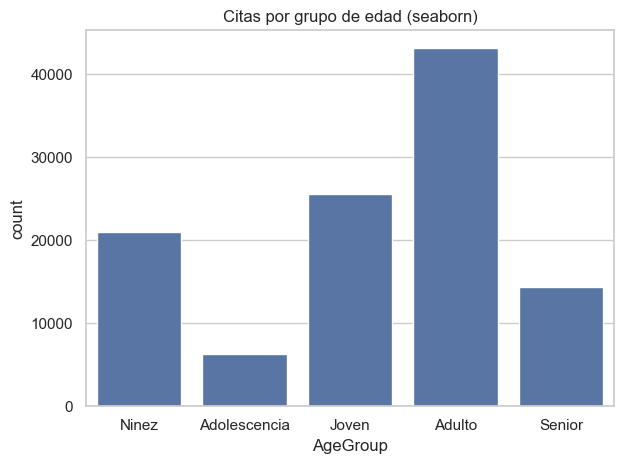

In [4]:
# Mismo grafico: volumen de citas por grupo de edad.

# --- matplotlib (motor): tu cuentas y etiquetas ---
counts = df["AgeGroup"].value_counts(sort=False)      # tu agregas: cuantas citas por grupo
fig, ax = plt.subplots(figsize=(7, 4))                # crea lienzo (fig) y ejes (ax)
ax.bar(counts.index.astype(str), counts.values)       # dibuja barras: x = grupo, y = conteo
ax.set_title("Citas por grupo de edad (matplotlib)")  # titulo (lo pones tu)
ax.set_ylabel("Numero de citas")                      # etiqueta del eje Y (la pones tu)
plt.tight_layout()
plt.show()

# --- seaborn (coche): una linea, cuenta y estiliza por ti ---
sns.countplot(data=df, x="AgeGroup")                  # recibe DataFrame + columna: cuenta y dibuja solo
plt.title("Citas por grupo de edad (seaborn)")
plt.tight_layout()
plt.show()

## 3.4.- Anatomia matplotlib: un grafico "a mano"

El motor por dentro, linea a linea. Es la version manual de lo que seaborn hace en una linea.


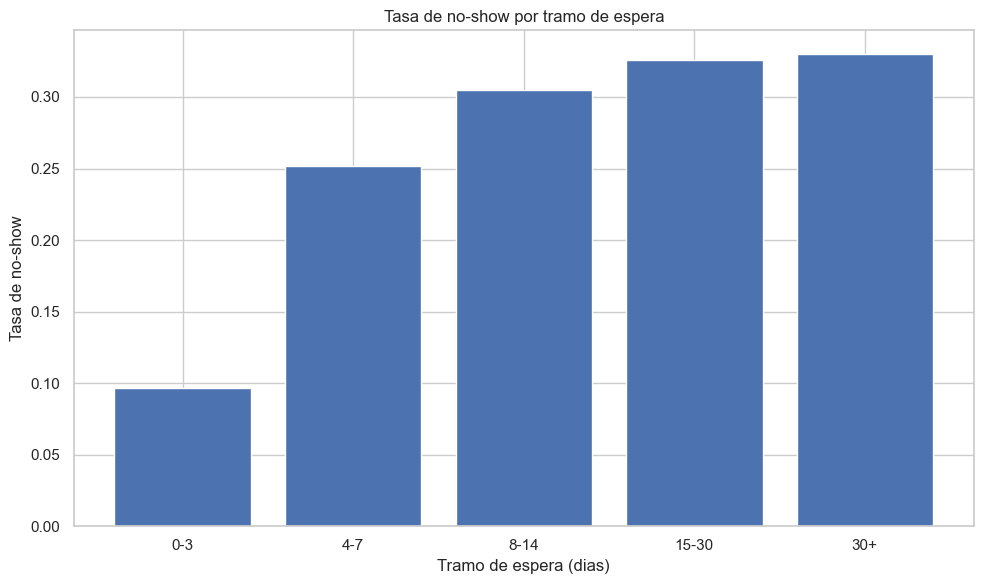

In [5]:
rate_by_bin = df.groupby("WaitingBin", observed=True)["NoShow"].mean()  # agrega: tasa media por tramo
fig, ax = plt.subplots(figsize=(10, 6))                  # crea figura (lienzo) y ejes (donde se dibuja)
ax.bar(rate_by_bin.index.astype(str), rate_by_bin.values)  # dibuja barras: x = tramos, y = tasa
ax.set_title("Tasa de no-show por tramo de espera")      # titulo del grafico
ax.set_xlabel("Tramo de espera (dias)")                  # etiqueta del eje X
ax.set_ylabel("Tasa de no-show")                         # etiqueta del eje Y
ax.grid(True, axis="y")                                  # rejilla horizontal para leer alturas
plt.tight_layout()                                       # ajusta margenes para que nada se solape
plt.show()                                               # renderiza la figura

## 3.5.- Set de herramientas: galeria por familia

El menu completo, sobre nuestro propio caso. Una sola tabla con las 4 familias,
sus graficos y cuando usar cada uno; debajo, una figura por familia.

| Familia | Pregunta | Grafico | Cuando usarlo | Funcion |
|---|---|---|---|---|
| **Distribucion** | ¿como se reparte una variable? | histograma | forma y picos | `sns.histplot` |
| | | KDE | forma suavizada (densidad) | `sns.kdeplot` |
| | | boxplot | mediana, cuartiles, outliers | `sns.boxplot` |
| | | violin | forma + cuartiles | `sns.violinplot` |
| **Comparacion** | ¿quien tiene mas? | barras | una metrica entre categorias | `sns.barplot` |
| | | countplot | volumen por categoria | `sns.countplot` |
| | | barras agrupadas | dos categorias a la vez | `sns.barplot(hue=)` |
| | | pointplot | tendencia entre categorias | `sns.pointplot` |
| **Relacion** | ¿como se relacionan dos variables? | scatter | dos numericas | `sns.scatterplot` |
| | | lineplot | metrica sobre un eje ordenado | `sns.lineplot` |
| | | heatmap | matriz de correlaciones | `sns.heatmap` |
| | | regplot | scatter + tendencia | `sns.regplot` |
| **Composicion** | ¿de que esta hecho el todo? | barras apiladas 100 % | partes de un total (desde **tabla resumen**) | 1) `crosstab(normalize)` -> 2) `.plot(stacked=True)` |
| | | histograma apilado | composicion de una distribucion (desde **df largo**) | `sns.histplot(multiple="stack")` |
| | | pie chart | **evitar** (el ojo compara mal angulos) | `plt.pie` (anti-ejemplo) |

> **Como leer las figuras:** usan una **rejilla de subplots** — `fig, axes = plt.subplots(filas, columnas)` crea la cuadricula, cada `axes[i, j]` es un panel y `ax=axes[i, j]` le dice a seaborn donde dibujar.


### 3.5.1.- Distribucion

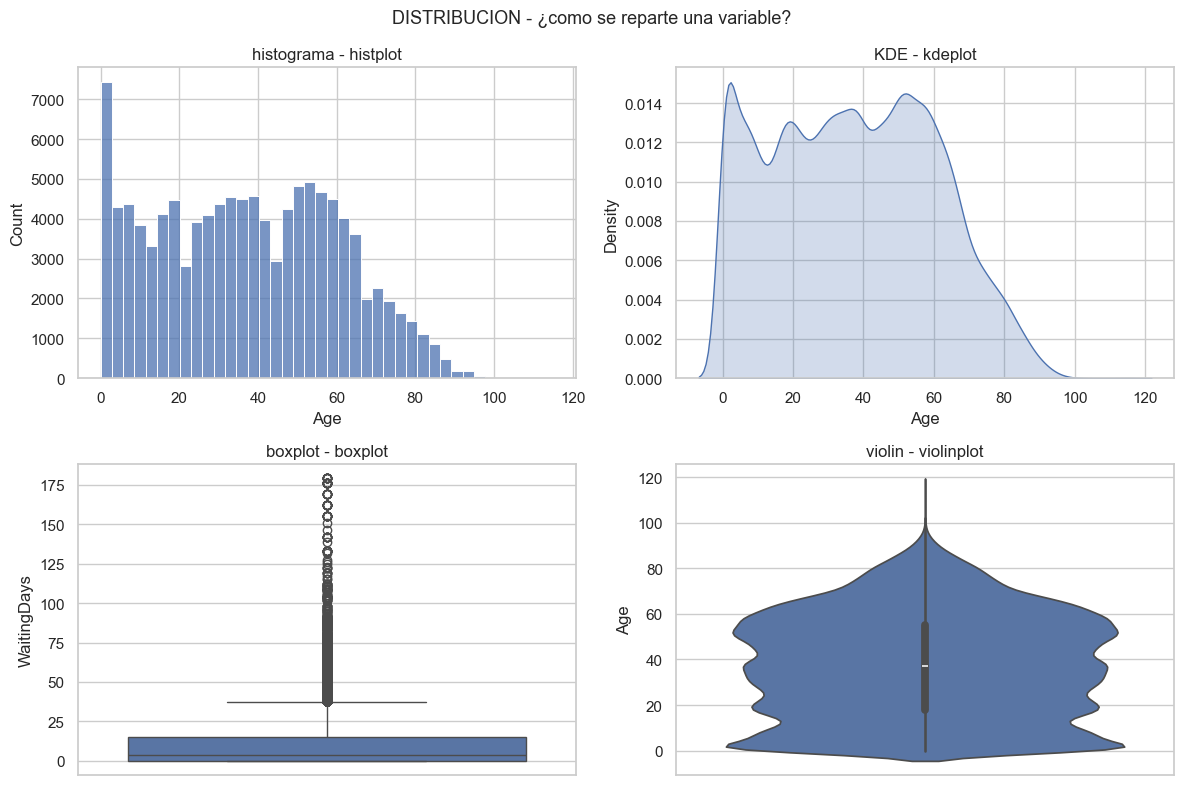

In [6]:
# Rejilla de subplots: 2 filas x 2 columnas. axes[fila, col] es cada panel.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x="Age", bins=40, ax=axes[0, 0])    # ax= indica a seaborn EN QUE panel dibujar
axes[0, 0].set_title("histograma - histplot")

sns.kdeplot(data=df, x="Age", fill=True, ax=axes[0, 1])   # densidad suavizada de la misma variable
axes[0, 1].set_title("KDE - kdeplot")

sns.boxplot(data=df, y="WaitingDays", ax=axes[1, 0])      # mediana, cuartiles y outliers
axes[1, 0].set_title("boxplot - boxplot")

sns.violinplot(data=df, y="Age", ax=axes[1, 1])           # forma (densidad) + cuartiles
axes[1, 1].set_title("violin - violinplot")

fig.suptitle("DISTRIBUCION - ¿como se reparte una variable?", fontsize=13)  # titulo comun de la figura
plt.tight_layout()
plt.show()

### 3.5.2.- Comparacion

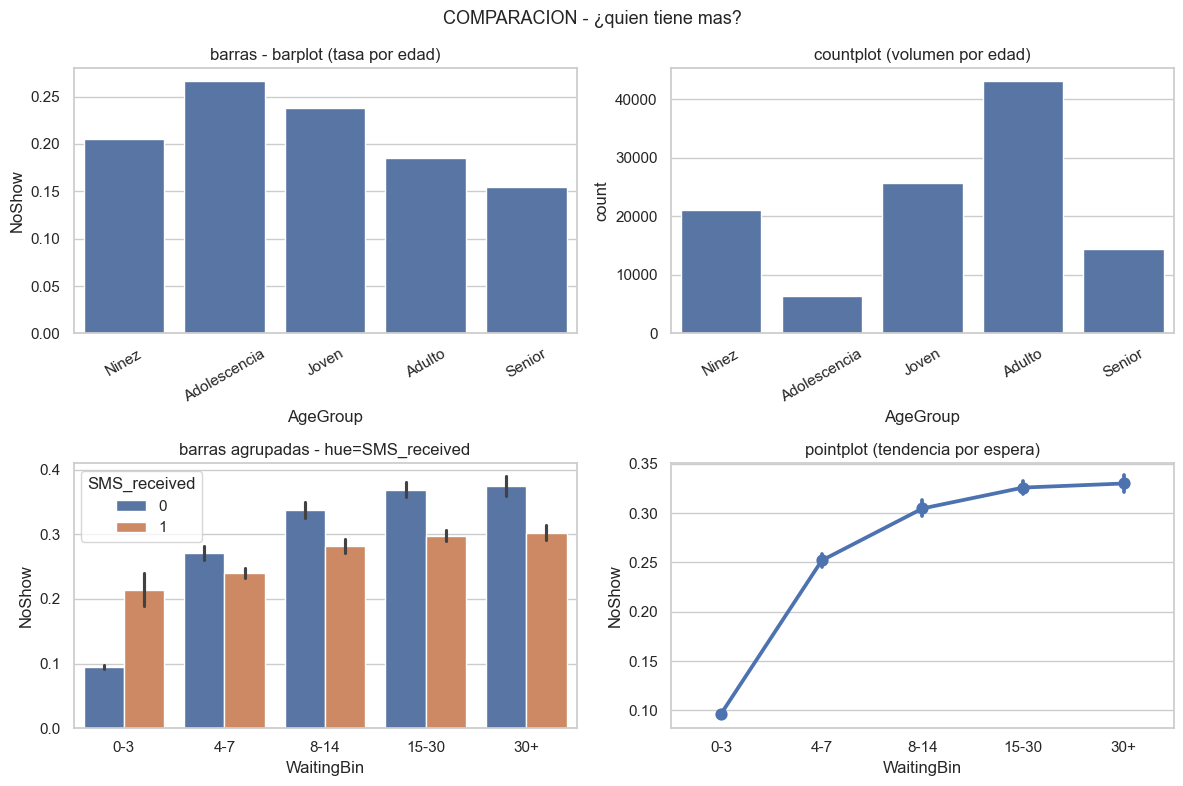

In [7]:
# Misma rejilla 2x2 (ver 3.5.1): cada sns.*(..., ax=axes[i, j]) dibuja en un panel.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

rate_age = df.groupby("AgeGroup", observed=True)["NoShow"].mean().reset_index()  # tasa por grupo de edad
sns.barplot(data=rate_age, x="AgeGroup", y="NoShow", ax=axes[0, 0])   # barras: compara una metrica (tasa)
axes[0, 0].set_title("barras - barplot (tasa por edad)")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="AgeGroup", ax=axes[0, 1])                   # countplot: compara volumen (conteo)
axes[0, 1].set_title("countplot (volumen por edad)")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=df, x="WaitingBin", y="NoShow", hue="SMS_received", ax=axes[1, 0])  # hue: dos categorias a la vez
axes[1, 0].set_title("barras agrupadas - hue=SMS_received")

sns.pointplot(data=df, x="WaitingBin", y="NoShow", ax=axes[1, 1])     # pointplot: marca la tendencia
axes[1, 1].set_title("pointplot (tendencia por espera)")

fig.suptitle("COMPARACION - ¿quien tiene mas?", fontsize=13)
plt.tight_layout()
plt.show()

### 3.5.3.- Relacion

Esta familia cruza **dos** variables, asi que necesita una vista a nivel de barrio
(tasa y volumen por barrio, igual que el `neigh_rate` de S03-B7). La creamos aqui,
justo donde se usa:


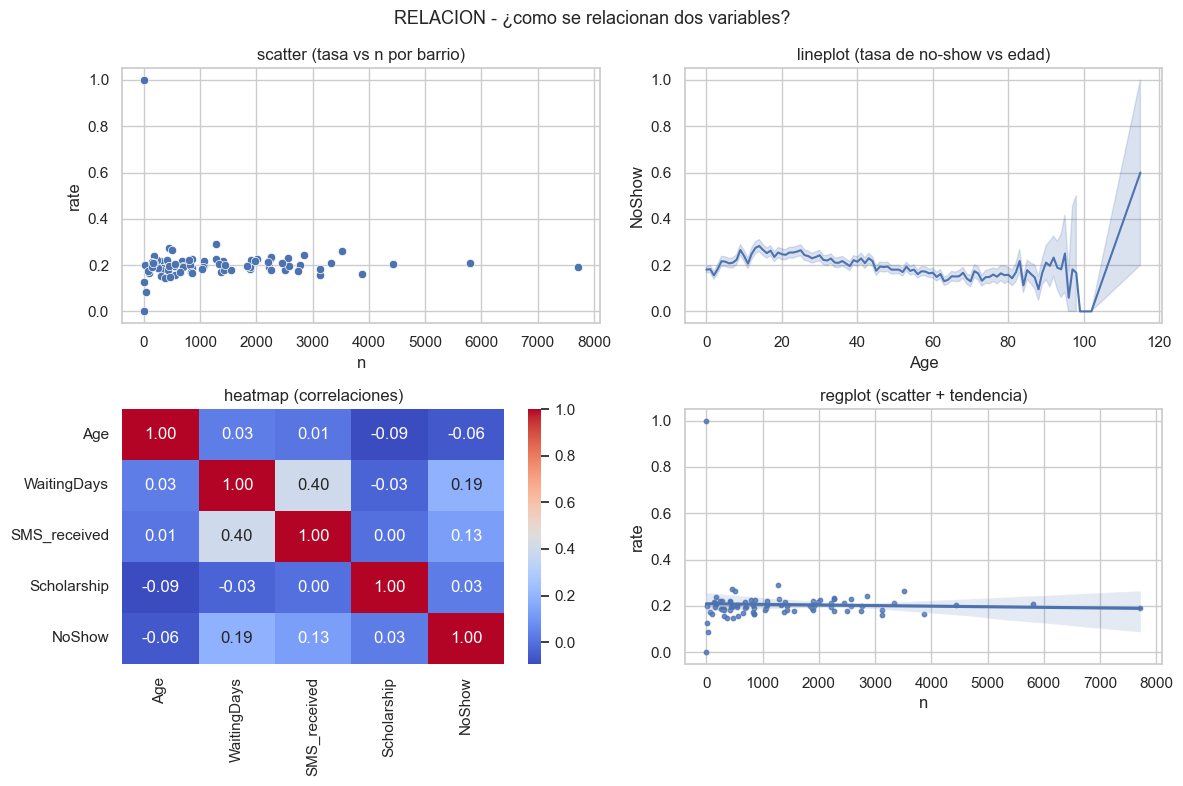

In [8]:
# Esta familia cruza DOS variables; una vista a nivel de barrio la habilita.
# Misma rejilla 2x2 (ver 3.5.1).
neigh_level = df.groupby("Neighbourhood").agg(             # una fila por barrio (como el neigh_rate de S03-B7)
    rate=("NoShow", "mean"), n=("NoShow", "size")).reset_index()
num_cols = ["Age", "WaitingDays", "SMS_received", "Scholarship", "NoShow"]  # numericas para correlacionar

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.scatterplot(data=neigh_level, x="n", y="rate", ax=axes[0, 0])    # dos numericas: tasa vs volumen por barrio
axes[0, 0].set_title("scatter (tasa vs n por barrio)")

sns.lineplot(data=df, x="Age", y="NoShow", ax=axes[0, 1])            # metrica sobre un eje ordenado (edad)
axes[0, 1].set_title("lineplot (tasa de no-show vs edad)")

sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 0])  # matriz de correlaciones
axes[1, 0].set_title("heatmap (correlaciones)")

sns.regplot(data=neigh_level, x="n", y="rate", scatter_kws={"s": 10}, ax=axes[1, 1])  # scatter + linea de tendencia
axes[1, 1].set_title("regplot (scatter + tendencia)")

fig.suptitle("RELACION - ¿como se relacionan dos variables?", fontsize=13)
plt.tight_layout()
plt.show()

### 3.5.4.- Composicion

Hasta aqui casi todos los graficos partian del DataFrame **largo** y los dibujaba
seaborn. Composicion introduce un caso nuevo: primero **resumimos** en una tabla
(`crosstab`) y luego **graficamos esa tabla**. Con la tabla ya construida,
`pandas.plot()` es la via mas directa a las barras apiladas.


In [9]:
# Paso 1: resumir. crosstab -> tabla de composicion (% de NoShow por grupo de edad).
comp = pd.crosstab(df["AgeGroup"], df["NoShow"], normalize="index")
comp.round(2)

NoShow,0,1
AgeGroup,,
Ninez,0.80,0.20
Adolescencia,0.73,0.27
Joven,0.76,0.24
Adulto,0.81,0.19
Senior,0.85,0.15


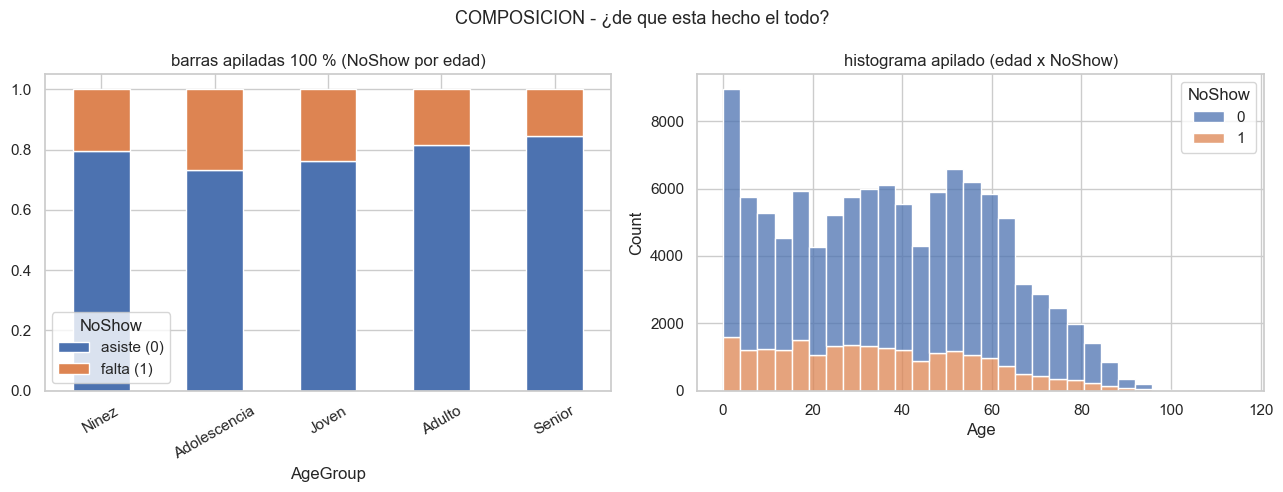

In [10]:
# Paso 2: graficar la tabla resumen. comp ya existe; pandas.plot la dibuja directo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comp.plot(kind="bar", stacked=True, ax=axes[0])              # tabla resumen -> barras apiladas (pandas)
axes[0].set_title("barras apiladas 100 % (NoShow por edad)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="NoShow", labels=["asiste (0)", "falta (1)"])

sns.histplot(data=df, x="Age", hue="NoShow", multiple="stack", bins=30, ax=axes[1])  # desde el df largo (seaborn)
axes[1].set_title("histograma apilado (edad x NoShow)")

fig.suptitle("COMPOSICION - ¿de que esta hecho el todo?", fontsize=13)
plt.tight_layout()
plt.show()

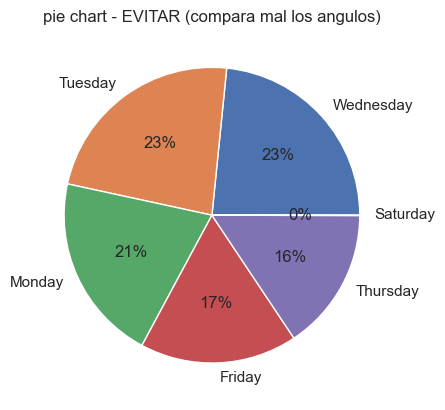

In [11]:
# Anti-ejemplo: el pie chart. Se desaconseja porque el ojo compara mal los angulos.
# Misma informacion -> mejor en barras (arriba). Lo mostramos para que juzgues por que evitarlo.
weekday_share = df["AppointmentWeekday"].value_counts()
plt.pie(weekday_share.values, labels=weekday_share.index, autopct="%1.0f%%")
plt.title("pie chart - EVITAR (compara mal los angulos)")
plt.show()

Ese es el menu. En B2 elegimos, para cada hipotesis de S03, **un** grafico y lo leemos.


# 4.- B2 - Set base: predice, revela, lee

> Lente principal: `EDA + PECO`. Cuatro graficos, uno por familia, atados a las hipotesis de S03.
> Patron: lees la pregunta -> escribes que familia y grafico -> ejecutas -> lees el insight.


## 4.1.- Como leer un grafico sin engañarnos

1. ¿Que pregunta responde?
2. ¿Que dice el patron?
3. ¿Que NO podemos concluir? (tasa sin volumen engaña; correlacion != causalidad)


## 4.1.1.- Vista general rapida: mapa de correlaciones

Antes de las hipotesis concretas, un **radar exploratorio**: las asociaciones lineales
entre las variables numericas. (Viste el heatmap como *tipo* en la galeria 3.5.3; aqui
lo usamos de verdad, con todas las numericas.)

> **Orienta, no decide.** La correlacion lineal no capta efectos por tramos ni
> causalidad; solo sugiere donde puede haber senal.


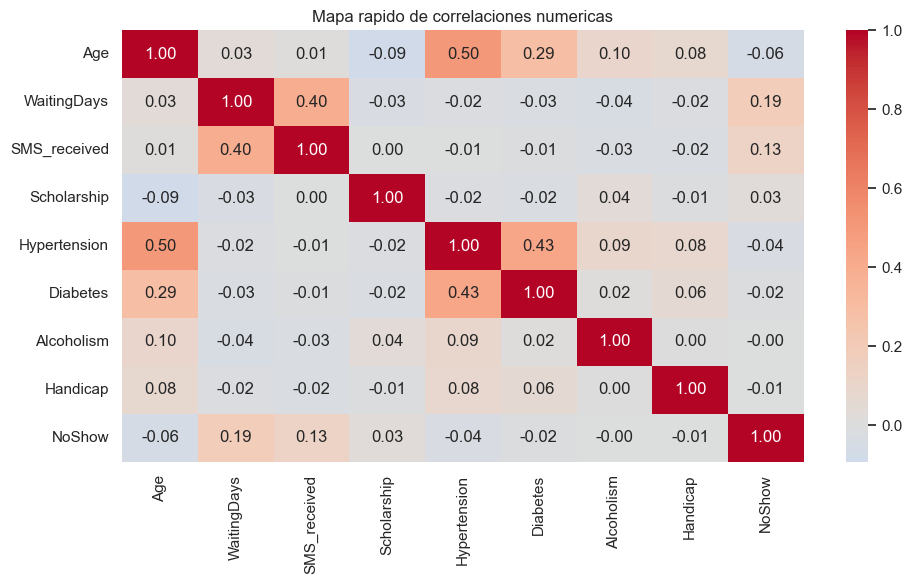

In [12]:
# Radar: asociacion lineal entre las variables numericas (incluida la objetivo).
num_cols = ["Age", "WaitingDays", "SMS_received", "Scholarship", "Hypertension",
            "Diabetes", "Alcoholism", "Handicap", "NoShow"]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)  # center=0: diverge en 0
plt.title("Mapa rapido de correlaciones numericas")
plt.tight_layout()
plt.show()

**Lectura del radar:** ninguna correlacion lineal es fuerte — la mayor es
`WaitingDays` (~0,19), luego `SMS_received` (~0,13), y el resto ronda 0. Mensaje clave:
**si la señal no esta en la correlacion lineal, estara en los segmentos.** Por eso el
analisis de hoy compara **tasas por categoria** (G2 `WaitingBin`, G3 edad x espera, G4
barrio), no coeficientes de correlacion. El radar ya apunta a la espera; G1-G4 lo
confirman con disciplina.


## 4.2.- G1 - Distribucion

**Pregunta:** ¿Como se reparte la espera entre todas las citas?

> **Predice** (antes de ejecutar): familia y grafico? `____________`


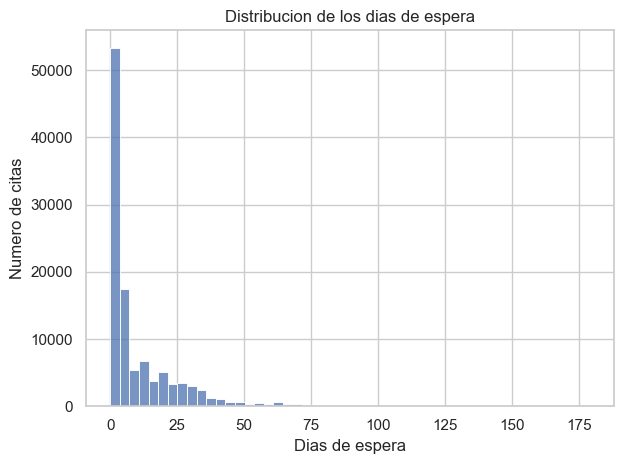

In [13]:
sns.histplot(data=df, x="WaitingDays", bins=50)
plt.title("Distribucion de los dias de espera")
plt.xlabel("Dias de espera")
plt.ylabel("Numero de citas")
plt.tight_layout()
plt.show()

**Lectura G1:** asimetria extrema. La mayoria de citas se piden con 0-3 dias de
antelacion; la cola larga (hasta ~179) es minoria pero concentra mas no-show. Por eso
bineamos (`WaitingBin`): comparar 0-3 vs 30+ es accionable; dia 7 vs dia 8 es ruido.


## 4.3.- G2 - Comparacion (H1: espera)

**Pregunta:** ¿Sube el no-show con la espera?

> **Predice:** familia y grafico? `____________`


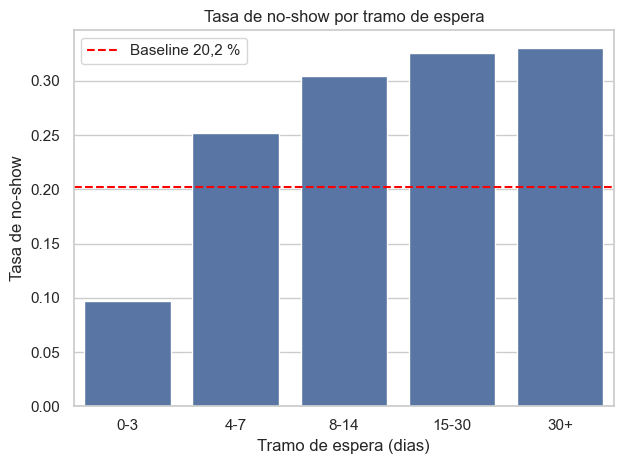

In [14]:
rate_bin = df.groupby("WaitingBin", observed=True)["NoShow"].mean().reset_index()
sns.barplot(data=rate_bin, x="WaitingBin", y="NoShow")
plt.axhline(0.202, color="red", linestyle="--", label="Baseline 20,2 %")
plt.title("Tasa de no-show por tramo de espera")
plt.xlabel("Tramo de espera (dias)")
plt.ylabel("Tasa de no-show")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura G2 (H1):** la espera es una **palanca clara**. Por encima de 4 dias se
supera el baseline; el tramo 30+ casi triplica al 0-3. Decision: reforzar recordatorios
en esperas largas. Limite: asociacion **observacional**.


## 4.4.- G3 - Relacion (H2: edad)

**Pregunta:** ¿Edad y espera juntas: cual domina?

> **Predice:** familia y grafico? `____________`


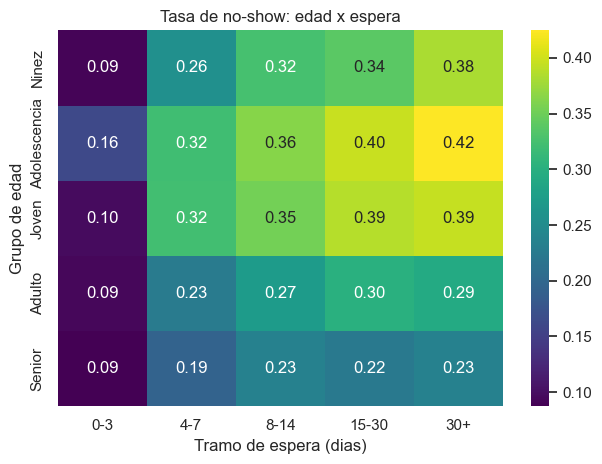

In [15]:
pivot = pd.pivot_table(df, values="NoShow", index="AgeGroup",
                       columns="WaitingBin", aggfunc="mean", observed=True)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Tasa de no-show: edad x espera")
plt.xlabel("Tramo de espera (dias)")
plt.ylabel("Grupo de edad")
plt.tight_layout()
plt.show()

**Lectura G3 (H2):** el gradiente **horizontal** (espera) es mas fuerte que el
**vertical** (edad): la espera domina, la edad **modula**. Celda alta Adolescencia·30+
(~0,43), baja Senior·0-3 (~0,09). El exceso joven no se explica solo por esperar mas.


## 4.5.- G4 - Comparacion (H3: barrio)

**Pregunta:** ¿Hay barrios de alto riesgo de verdad?

> **Predice:** familia y grafico? `____________`


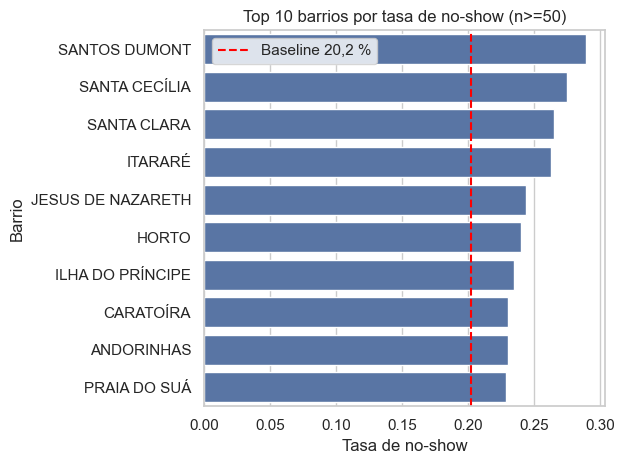

In [16]:
neigh = df.groupby("Neighbourhood").agg(
    rate=("NoShow", "mean"), n=("NoShow", "size")).reset_index()
reliable = neigh[neigh["n"] >= 50].sort_values("rate", ascending=False).head(10)
sns.barplot(data=reliable, x="rate", y="Neighbourhood")
plt.axvline(0.202, color="red", linestyle="--", label="Baseline 20,2 %")  # baseline (barras horizontales -> linea vertical)
plt.title("Top 10 barrios por tasa de no-show (n>=50)")
plt.xlabel("Tasa de no-show")
plt.ylabel("Barrio")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura G4 (H3):** hay barrios estructuralmente por encima del baseline. El filtro
`n >= 50` es esencial: **sin el**, el barrio con 2 citas y tasa 100 % (S03) encabezaria
el grafico. Un grafico hereda la calidad de la tabla que lo alimenta.


## 4.6.- Familia Composicion (vocabulario)

**Composicion** responde "¿de que esta hecho el todo?": barras apiladas al 100 %, no
pie chart. Ejemplo para tu TFM: % de no-show dentro de barrios `Hotspot` vs resto. Lo
dejamos como vocabulario para no inflar el set de hoy.


# 5.- B3 - Prompt-clinic de visualizacion + cierre Bloque 1

> Lente principal: `LLM-prompt + comunicacion visual`.


## 5.1.- Pedir un grafico sin que invente columnas

**Prompt malo:** `Hazme un grafico bonito del no-show.`

**Prompt bueno:**
> DataFrame `df` (citas medicas) con la columna categorica `WaitingBin`
> (`"0-3"`, `"4-7"`, `"8-14"`, `"15-30"`, `"30+"`) y `NoShow` (0/1). Usando **solo
> seaborn y matplotlib**, genera un barplot de la **tasa media** de `NoShow` por
> `WaitingBin`, titulo en español, linea de baseline en `0.202`, `figsize=(10, 6)`.
> No inventes columnas ni uses plotly.

El malo elige el grafico por ti e inventa columnas; el bueno fija familia, columnas,
herramienta y formato -> codigo verificable.

> **Microejercicio (90 s):** reformula el prompt para un grafico de tu TFM.


## 5.2.- Cierre Bloque 1 - graficos -> Canvas

| Grafico | Hipotesis | Casilla | Frase de negocio |
|---|---|---|---|
| G2 | H1 espera | 5 / 6 | "refuerza recordatorios en esperas largas" |
| G3 | H2 edad | 5 | "la edad modula, no decide" |
| G4 | H3 barrio | 5 / 6 | "prioriza barrios hotspot" |

**Un grafico = una hipotesis = una frase de negocio.**


# 6.- B4 - Reel condensado del viaje S01 -> S04

> Lente principal: `CRISP-DM (6 fases en miniatura)`. El curso fue recorrer un proyecto
> de datos, no aprender Pandas. Aqui, comprimido.


In [17]:
# El viaje entero en pocas lineas. Cada comentario nombra la fase/lente.

# [CRISP: Data Understanding | leer el original]
raw = pd.read_csv(RAW_PATH)
print("crudo:", raw.shape)

# [CRISP: Data Preparation | tus funciones de S03, reproducibles]
df = enrich_with_neighbourhood_rate(prepare(raw))
print("preparado:", df.shape)

# [EDA: objetivo | baseline]
print("baseline no-show:", round(df["NoShow"].mean(), 3))

# [PECO: H1 | comparar tasas por palanca]
print("\ntasa por tramo de espera:")
print(df.groupby("WaitingBin", observed=True)["NoShow"].mean().round(3))

# [comunicacion visual | el grafico de B2]   -> sns.barplot(...)  (G2)
# [decision | hacia Evaluation/Deployment]   -> recordatorios en esperas > 14 d

crudo: (110527, 14)
preparado: (110521, 24)
baseline no-show: 0.202

tasa por tramo de espera:
WaitingBin
0-3      0.097
4-7      0.252
8-14     0.305
15-30    0.326
30+      0.330
Name: NoShow, dtype: float64


## 6.1.- El grafico, en su forma minima

Cuando ya sabes **que** preguntar, explorar es **una linea**: seaborn dibuja sin
`fig, ax` ni titulos. Eso es viz **exploratoria** (rapida, para ti). La viz
**explicativa** —titulo, baseline, ejes en español, como en B1— se pule solo para
el grafico que vas a **comunicar**.


<Axes: xlabel='Age', ylabel='Count'>

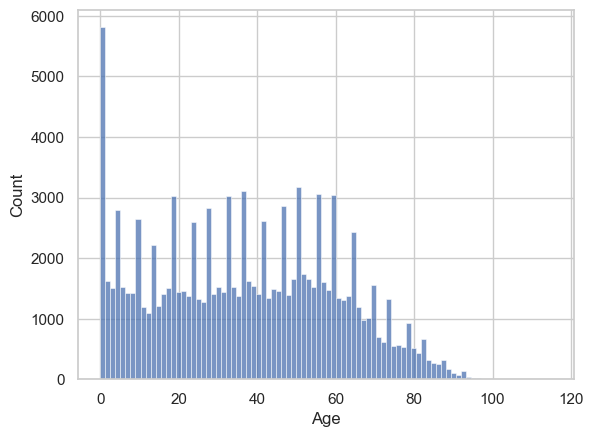

In [18]:
sns.histplot(data=df, x="Age", bins=90)            # distribucion, en 1 linea

<Axes: xlabel='WaitingBin', ylabel='NoShow'>

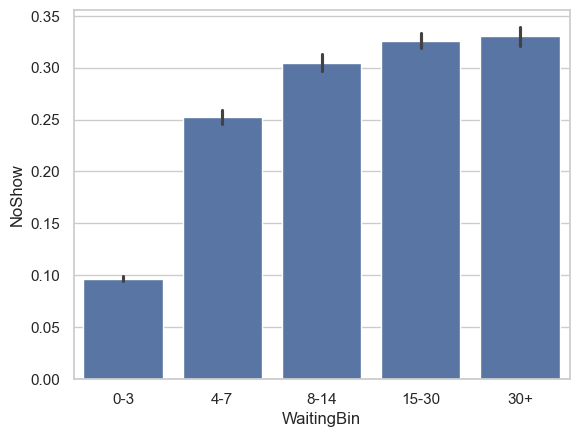

In [19]:
sns.barplot(data=df, x="WaitingBin", y="NoShow")   # H1 (tasa por espera), en 1 linea

## 6.2.- Programar vs pensar

La **sintaxis** (`groupby`, `pd.cut`, `sns.barplot`) la genera un copilot. Lo que **no**
delegas: que pregunta, que columna, que validacion, que lectura. El valor esta en las
decisiones, no en recordar la API (regla de oro, MARCO 3.6).


## 6.3.- El reel sobre CRISP-DM

| Sesiones | Fase | Que hicimos |
|---|---|---|
| S01-S04 | Business + Data Understanding + Preparation + comunicacion | **describir y entender** |
| S05-S10 | Modeling / Evaluation | predecir / explicar |
| S11 | Deployment | entregar |

**El metodo es el mismo; cambia la herramienta.**


# 7.- B5 - Worksheet agnostico: como abordar cualquier caso

> Lente principal: `MARCO sec 5`. Del reel abstraemos una plantilla de 6 preguntas
> reutilizable en cualquier caso.


## 7.1.- Las 6 preguntas

1. ¿Que **fase CRISP-DM**?
2. ¿Que **pregunta de negocio / hipotesis PECO**?
3. ¿Que **KPI y baseline**?
4. ¿Que **riesgo DAMA**?
5. ¿Que **validar** antes de interpretar?
6. ¿Que **decision** o siguiente pregunta?

> Si un analisis no responde estas 6, es **tecnica sin contexto**.


## 7.2.- Ejemplo resuelto - el No-Show

| # | Pregunta | Respuesta |
|---|---|---|
| 1 | Fase | Data Understanding (hoy, visual) |
| 2 | Pregunta / PECO | ¿la espera sube el no-show? (H1) |
| 3 | KPI / baseline | tasa de no-show; 20,2 % |
| 4 | Riesgo DAMA | validez (esperas negativas), unicidad (cita vs paciente) |
| 5 | Que validar | tasa **y** denominador; filtrar n>=50 antes de graficar |
| 6 | Decision | recordatorios en esperas > 14 d |


## 7.3.- Transferencia (90 s)

**Mini-caso:** _una tienda online quiere reducir la tasa de carritos abandonados._

Rellena las 6 casillas **en papel** para este caso (no es el No-Show). El metodo es
transferible: el No-Show fue el vehiculo, no el destino.


# 8.- B6 - Cierre del Project Canvas (v4)

> Lente principal: `CRISP-DM: Data Understanding documentado`. v1 (S01) -> v4 (hoy).


## 8.1.- Que actualizamos

Abre `S04_2604_canvas_update.md`:

- **Casilla 5:** cada hipotesis ilustrada con su grafico (H1 -> G2, H2 -> G3, H3 -> G4).
- **Casilla 6:** decision defendible + grafico que la respalda + limite.

| Decision | Grafico | Frase para el stakeholder |
|---|---|---|
| Recordatorios en esperas largas | G2 | "a mas espera, mas ausencia" |
| Priorizar barrios hotspot | G4 | "hay zonas de riesgo estructural" |
| No segmentar solo por edad | G3 | "la edad modula, la espera decide" |

El par "grafico + frase" es el formato de la presentacion de S12.


# 9.- B7 - Cierre y puente a S05

**Hoy cerramos:** pregunta -> familia -> grafico -> insight; el viaje S01-S04 en pocas
lineas; un worksheet agnostico; un Canvas defendible.

**Que viene:** hasta ahora **describimos**; desde **S05** (con David) **modelamos**:
¿podemos predecir o explicar el no-show? El dataset preparado de S03 es la entrada.

> **Las herramientas cambian, el metodo no.**
